# EDA


## Imports

In [1]:
import pandas as pd
import json
from tqdm.auto import tqdm
import numpy as np


import matplotlib.pyplot as plt
import seaborn

# matplotlib 한글폰트
import matplotlib.font_manager as fm


plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False



In [2]:
# constant
max_len = 54 # 계산된거 사용

# read file
matchDir = 'data/match/'
matchTimeLineDir = 'data/match_timeline/'
match_df = pd.read_csv('data/match_id_list.csv')

match_list = match_df['match_id'].tolist()

champion_df = pd.read_csv('챔프사전.csv')
champion_id_list = champion_df['key'].tolist()

## 포지션 값 검증
1,2,3,4,5/ 6,7,8,9,10 \
순서대로 탑,정글,미드,바텀,서폿여부에 대한 정보 검증 \
확인할 값 : \
match['info']['participants'][:]['individualPosition'] \
match['info']['participants'][:]['teamPosition'] \
match['info']['participants'][:]['role'] \
match['info']['participants'][:]['lane']

In [3]:
cols = ['match_id','participant_id','individual_position','team_position','role','lane']
lanetype_df = pd.DataFrame(columns=cols)
idx = 0

pID = []
champID = []
indPos = []
teamPos = []
role = []
lane = []
matchID = []

max_len = 0

for match in tqdm(match_list):
    match_file = matchDir + str(match) + '.json'
    with open(match_file) as f:
        matchData = json.load(f)
        f.close()
    # 다시하기 게임 제외
    if matchData['info']['gameDuration'] <= 360:
        continue
    llen = int( matchData['info']['gameDuration'] / 60 ) + 1
    if llen > max_len:
        max_len = llen
    # participant 정보 추출
    for participant in matchData['info']['participants']:
        matchID.append(match)
        pID.append(participant['participantId'])
        champID.append(participant['championId'])
        indPos.append(participant['individualPosition'])
        teamPos.append(participant['teamPosition'])
        role.append(participant['role'])
        lane.append(participant['lane'])



  0%|          | 0/60208 [00:00<?, ?it/s]

In [4]:
# 데이터프레임 생성       
lanetype_df = pd.DataFrame({
    'match_id': matchID,
    'participant_id': pID,
    'champion_id': champID,
    'individual_position': indPos,
    'team_position': teamPos,
    'role': role,
    'lane': lane
})

In [5]:
lanetype_df.to_csv('data/lanetype.csv', index=False)

In [6]:
# # case 1 participantId가 1인 경우
# for i in range(1,11,1):
#     ## unique value and count of each column for each pIDs
#     print('participant_id:',i)
#     print(f'individual_position: {lanetype_df[lanetype_df["participant_id"] == i]["individual_position"].value_counts()}')
#     print(f'team_position: {lanetype_df[lanetype_df["participant_id"] == i]["team_position"].value_counts()}')
#     print(f'role: {lanetype_df[lanetype_df["participant_id"] == i]["role"].value_counts()}')
#     print(f'lane: {lanetype_df[lanetype_df["participant_id"] == i]["lane"].value_counts()}')
#     print('-----------------------------------------')

## 챔피언별 오브젝트 획득 차트

### 챔피언별 획득 골드 평균

  0%|          | 0/60208 [00:00<?, ?it/s]

Text(0.5, 1.0, 'totalGold of champion 아트록스')

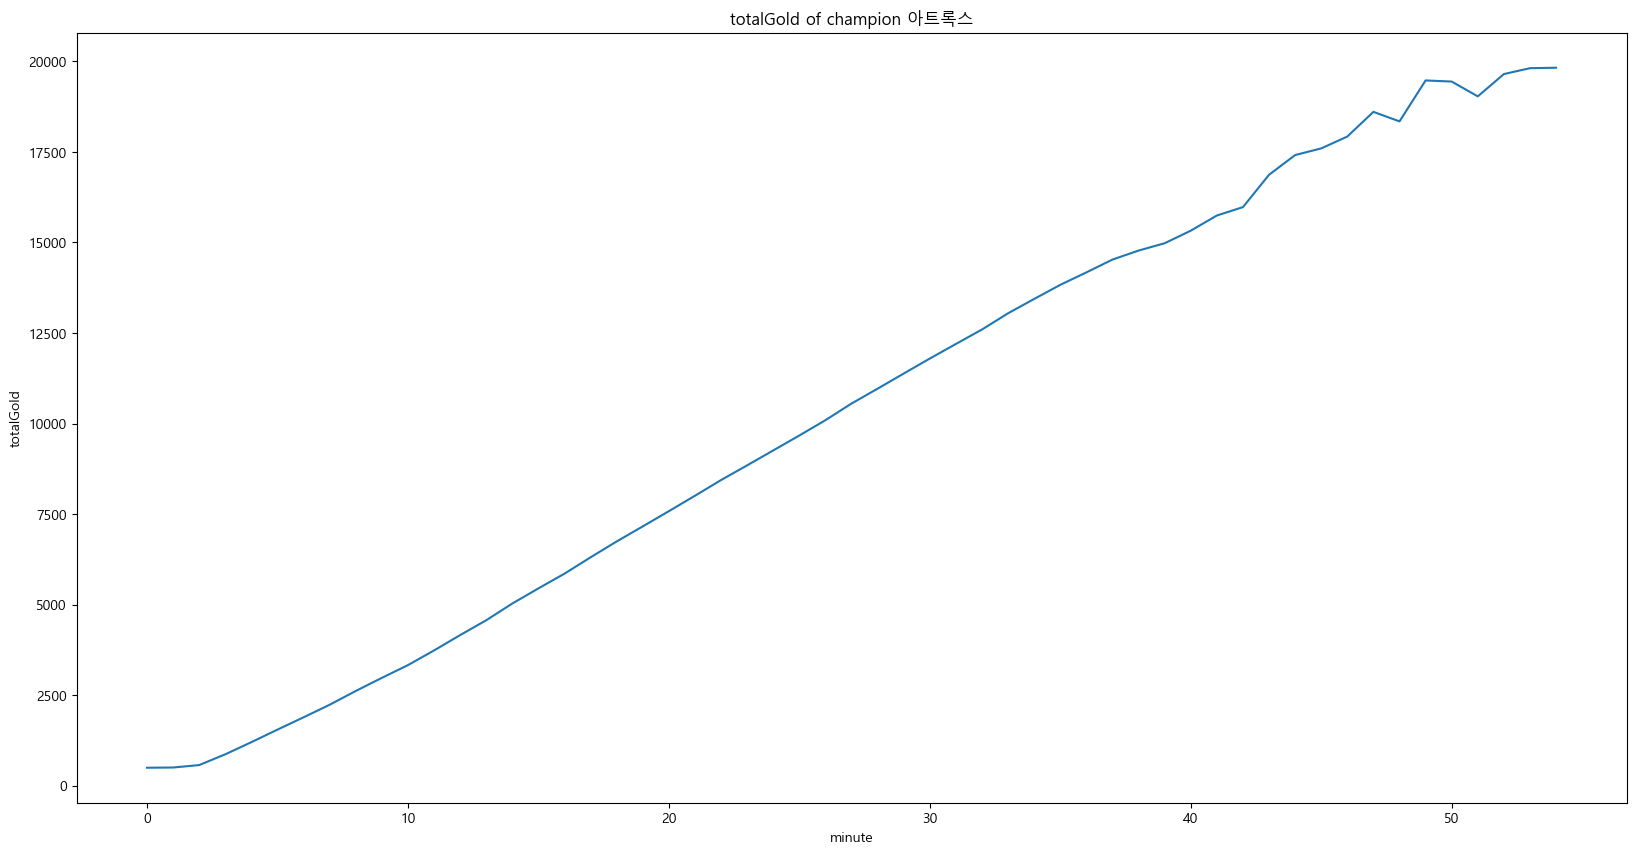

In [7]:
import numpy as np

# index: 0-167, key: champion_id

# x: average of totalGold for each champion, y: minute
# -1 : Nan
champCount = len(champion_id_list)+1
avgGold = np.zeros((champCount, max_len+1))
cnt = np.zeros((champCount, max_len+1))

for match in tqdm(match_list):
    match_file = matchDir + str(match) + '.json'
    match_tl_file = matchTimeLineDir + str(match) + '.json'

    with open(match_file) as f:
        match = json.load(f)
    with open(match_tl_file) as f:
        match_tl = json.load(f)

    if match['info']['gameDuration'] <= 360:
        continue
    
    for idx in range(10):
        champ_id = match['info']['participants'][idx]['championId']
        for (m,f) in enumerate(match_tl['info']['frames']):
            cnt[champion_id_list.index(champ_id)][m] += 1
            avgGold[champion_id_list.index(champ_id)][m] += f['participantFrames'][str(idx+1)]['totalGold']
            

avgGold = np.divide(avgGold, cnt, out=np.zeros_like(avgGold), where=cnt!=0)

import matplotlib.pyplot as plt
import seaborn

# 챔피언 한개 샘플
plt.figure(figsize=(20, 10))
plt.plot(avgGold[0], label='totalGold')
plt.xlabel('minute')
plt.ylabel('totalGold')
plt.title(f'totalGold of champion {champion_df[champion_df["key"] == champion_id_list[0]]["name"].values[0]}')

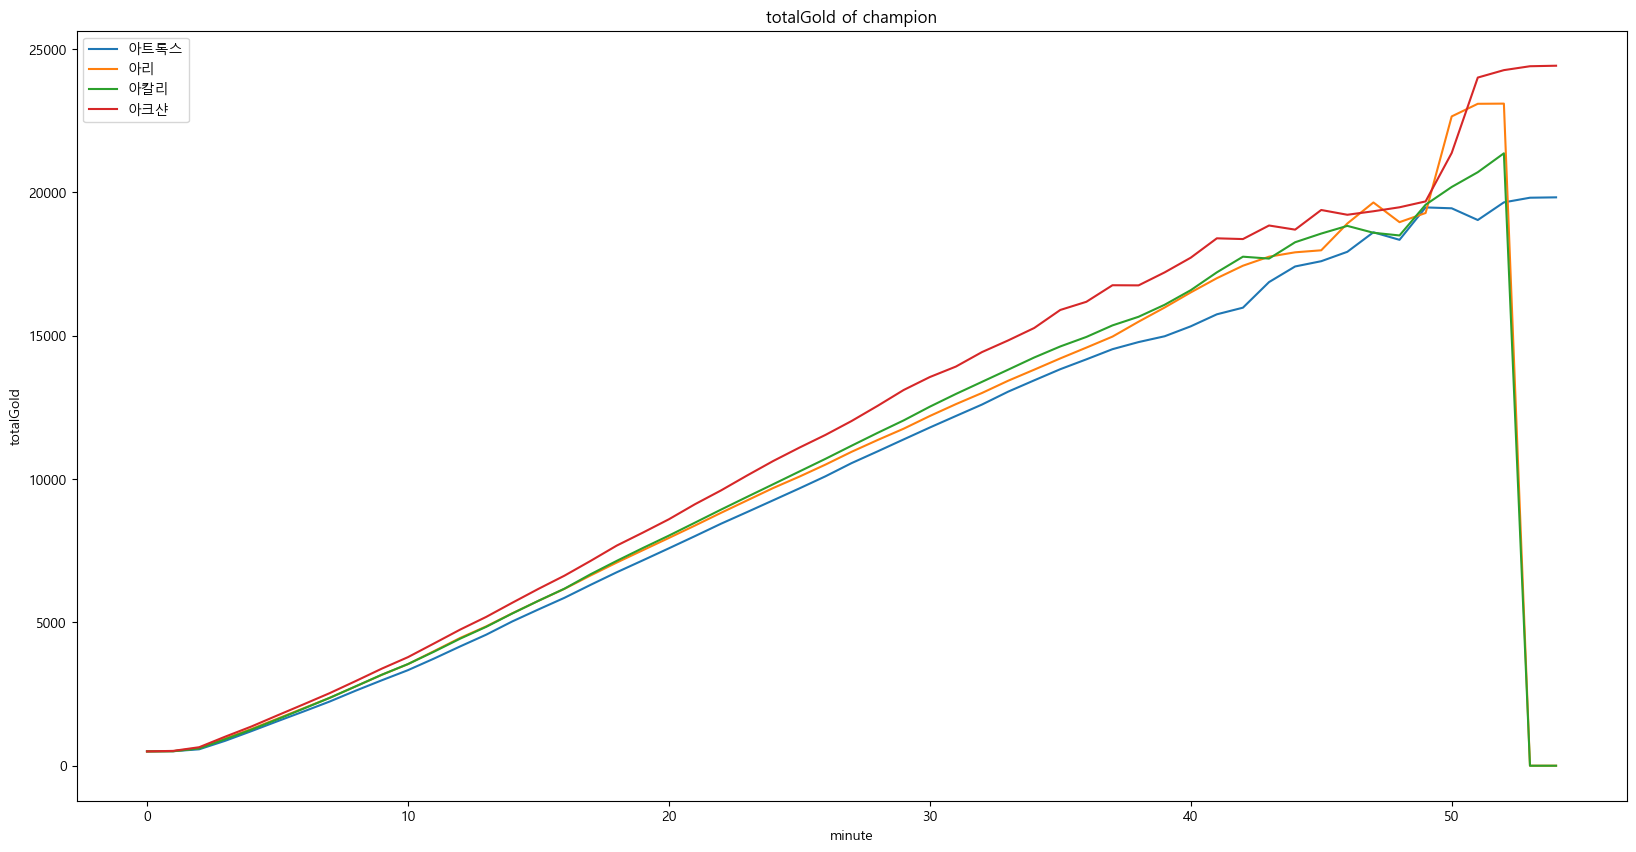

In [8]:
# 챔피언 4개 샘플
plt.figure(figsize=(20, 10))
for i in range(4):
    plt.plot(avgGold[champion_id_list.index(champion_id_list[i])], label=champion_df[champion_df["key"] == champion_id_list[i]]["name"].values[0])
    plt.xlabel('minute')
    plt.ylabel('totalGold')
    plt.title(f'totalGold of champion')
    plt.legend()

### 챔피언별 포탑파괴누적 평균(분당)

In [9]:
# index: 0-167, key: champion_id

# x: average of totalGold for each champion, y: minute
# -1 : Nan
champCount = len(champion_id_list)+1
avgTower = np.zeros((champCount, max_len+1))
cnt = np.zeros((champCount, max_len+1))

for match in tqdm(match_list):
    match_file = matchDir + str(match) + '.json'
    match_tl_file = matchTimeLineDir + str(match) + '.json'

    with open(match_file) as f:
        match = json.load(f)
    with open(match_tl_file) as f:
        match_tl = json.load(f)

    if match['info']['gameDuration'] <= 360:
        continue
    
    tower = np.zeros(max_len+1)
    for idx in range(10):
        champ_id = match['info']['participants'][idx]['championId']
        # frame
        for (m,f) in enumerate(match_tl['info']['frames']):
            # event
            for e in f['events']:
                # tower kill event
                if e['type'] == 'BUILDING_KILL':
                    # killer or assisting
                    if idx+1 == e['killerId']:
                        tower[m:] += 1
                    elif  'assistingParticipantIds' in e.keys():
                        if idx+1 in e['assistingParticipantIds']:
                            tower[m:] += 1

            cnt[champion_id_list.index(champ_id)][m] += 1
            avgTower[champion_id_list.index(champ_id)][m] += tower[m]
            

avgTower = np.divide(avgTower, cnt, out=np.zeros_like(avgTower), where=cnt!=0)


  0%|          | 0/60208 [00:00<?, ?it/s]

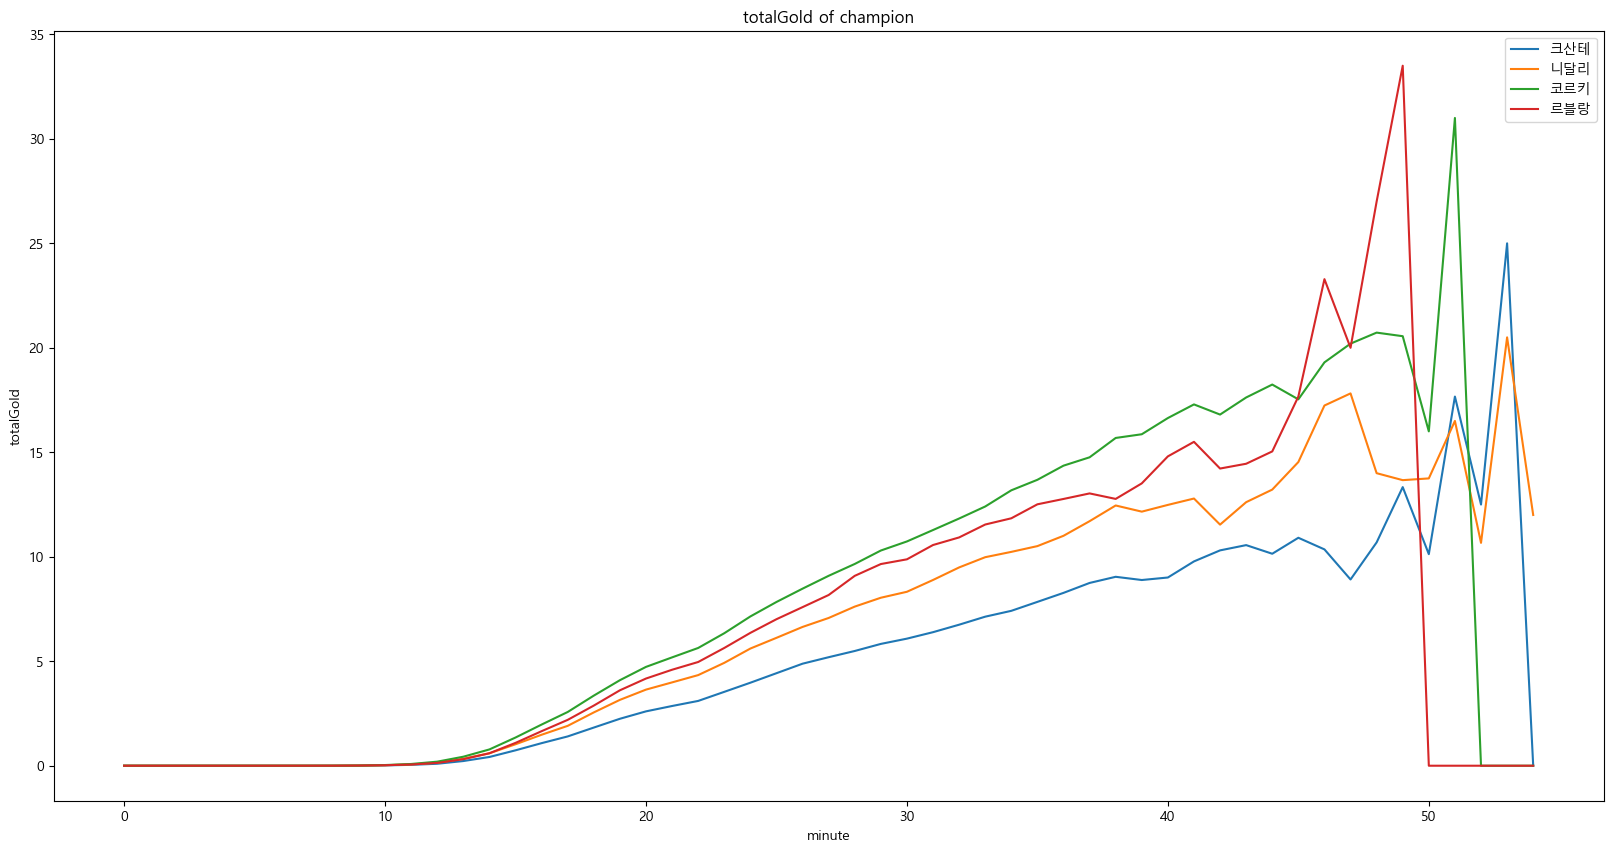

In [10]:
# 챔피언 4개 샘플
plt.figure(figsize=(20, 10))
for i in range(4):
    # random 4 champions
    rn = np.random.randint(0,168)
    plt.plot(avgTower[champion_id_list.index(champion_id_list[rn])], label=champion_df[champion_df["key"] == champion_id_list[rn]]["name"].values[0])
plt.xlabel('minute')
plt.ylabel('totalGold')
plt.title(f'totalGold of champion')
plt.legend()
plt.show()

## 이벤트 이후 골드획득 변화 추적 (5분)
1. 오브젝트
    1) 유충( 개수 별로 )
    2) 전령
    3) 용( 종류 별로 )
    4) 바론
    5) 장로
2. 완성 아이템별 
    1) 
3. 챔피언별 (스킬)레벨업

### 0) 골드 획득 변화, 전체에 대한 평균값

In [11]:
champCount = len(champion_id_list)+1
# avgGold = np.zeros((champCount, max_len+1))
# cnt = np.zeros((champCount, max_len+1))

# 골드 획득 변화량( 전체에 대해서 )
# 골드 획득 변화량( 챔피언 별 )

avgGold = np.zeros((champCount, max_len+1))
avgGoldDiff = np.zeros((max_len+1))
GoldDiff = np.zeros((champCount, max_len+1))
cnt = np.zeros((champCount, max_len+1))
totalcnt = np.zeros((max_len+1))

for match in tqdm(match_list):
    match_file = matchDir + str(match) + '.json'
    match_tl_file = matchTimeLineDir + str(match) + '.json'

    # read file
    with open(match_file) as f:
        match = json.load(f)
    with open(match_tl_file) as f:
        match_tl = json.load(f)

    if match['info']['gameDuration'] <= 360:
        continue
    
    # participoant 1-10
    for idx in range(10):
        champ_id = match['info']['participants'][idx]['championId']
        # for each frame
        for (m,f) in enumerate(match_tl['info']['frames']):
            # integrate gold
            cnt[champion_id_list.index(champ_id)][m] += 1
            avgGold[champion_id_list.index(champ_id)][m] += f['participantFrames'][str(idx+1)]['totalGold']
            # integrate gold differece
            GoldDiff[champion_id_list.index(champ_id)][m] += f['participantFrames'][str(idx+1)]['totalGold']
            # integrate total gold difference
            totalcnt[m] += 1
            avgGoldDiff[m] += f['participantFrames'][str(idx+1)]['totalGold']


  0%|          | 0/60208 [00:00<?, ?it/s]

In [12]:
GoldDiff = np.divide(GoldDiff, cnt, out=np.zeros_like(GoldDiff), where=cnt!=0)
avgGoldDiff = np.divide(avgGoldDiff, totalcnt, out=np.zeros_like(avgGoldDiff), where=totalcnt!=0)
avgGold = np.divide(avgGold, cnt, out=np.zeros_like(avgGold), where=cnt!=0)

avgGoldDiff[1:] = avgGoldDiff[1:] - avgGoldDiff[:-1]
for idx in range(168):
    GoldDiff[idx][1:] = avgGold[idx][1:] - avgGold[idx][:-1]

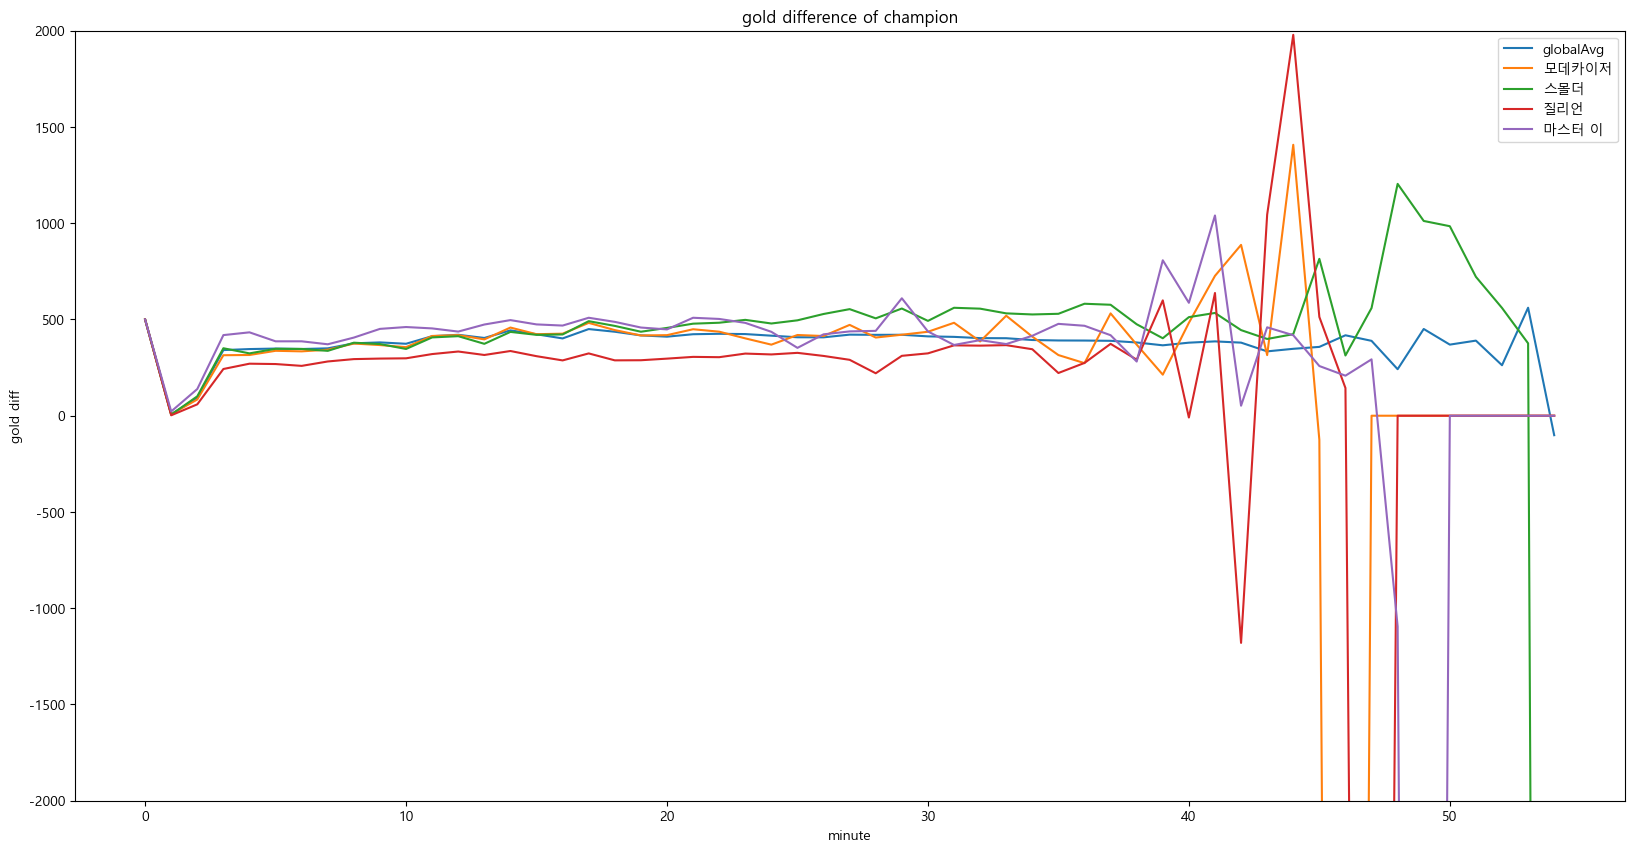

In [23]:
# plot total gold diff and champion gold diff
plt.figure(figsize=(20, 10))
plt.plot(avgGoldDiff, label='globalAvg')

for i in range(4):
    rn = np.random.randint(0,168)
    plt.plot(GoldDiff[champion_id_list.index(champion_id_list[rn])], label=champion_df[champion_df["key"] == champion_id_list[rn]]["name"].values[0])
plt.xlabel('minute')
plt.ylim(-2000,2000)
plt.ylabel('gold diff')
plt.title(f'gold difference of champion')
plt.legend()

plt.show()

### 1-1) 유충

In [14]:
target_event = "ELITE_MONSTER_KILL"
target_monster = "HORDE"